In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from anndata import AnnData
import scanpy as sc

# Data exploarition of the table used to annotate cell types
Questions:
1. The list of proteins that  are not used in the labelling are: 
    - 'EGFR',
    - 'Tbet', 
    - 'PD-L1',
    -  'CD366', 
    - 'HLA-DR-DQ-DP', 
    - 'VEGF', 
    - 'PD-1',
    -  'Collage-Type_I',
    -  'PD-L2', 
    - 'DNA2'
    
    I don't know all of them, but it seems strange that things like PD 1 are not used in the classification
2. The label 'Other cells', what does it refer to? How the markers have been chosen for this class?

 

Load the expert curated signature table

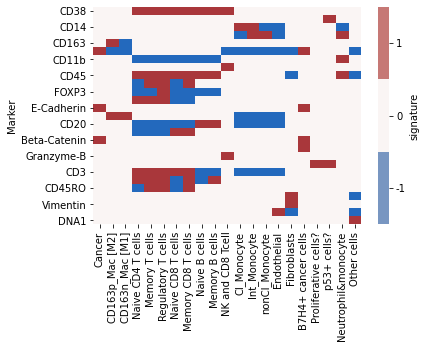

In [10]:
signature_sign = pd.read_csv('processed_files/cell_type_matrix.csv',index_col=0).fillna(0)
marker_list = (signature_sign!=0).any(axis = 1)
marker_list = list(marker_list[marker_list].index)
ax = sns.heatmap(signature_sign.loc[marker_list],cbar_kws={"boundaries": np.linspace(-1, 1, 4)},cmap='vlag')
colorbar = ax.collections[0].colorbar
colorbar.set_ticks([-0.667, 0, 0.667])
colorbar.set_ticklabels(['-1', '0', '1'])
colorbar.set_label('signature')

list of proteins not used as markers

In [4]:
set((signature_sign!=0).any(axis = 1).index)-set(marker_list)

{'CD366',
 'Collage-Type_I',
 'DNA2',
 'EGFR',
 'HLA-DR-DQ-DP',
 'PD-1',
 'PD-L1',
 'PD-L2',
 'Tbet',
 'VEGF'}

Text(0, 0.5, 'n. of markers')

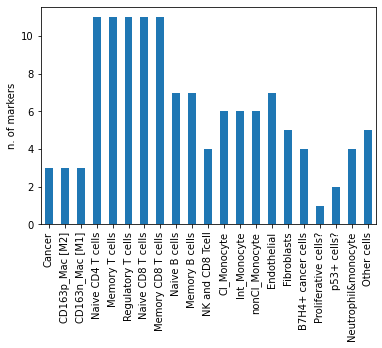

In [11]:
(signature_sign!=0).sum().plot(kind = 'bar')
plt.ylabel('n. of markers')

In [6]:
intensities = pd.read_csv('./processed_files/all_data_intensities.csv',index_col=0)
intensities.index = intensities.index.astype(str)
intensities['ROI'] = pd.to_numeric(intensities.ROI.str[-3:])#make ROI numeric
columns_to_extract = intensities.columns.difference(['ROI', 'source_file'])
intensities_protein = intensities[columns_to_extract]#contains only numeric values (intensities)
regions = pd.read_csv('./processed_files/all_data_regions.csv',index_col=0)
labels = pd.read_csv('output/trte_labels_ELM_IMC_T1D_AnnoSpat.csv')
num_labels = pd.read_csv('output/trte_labels_numericLabels_ELM_IMC_T1D_AnnoSpat.csv')
mapper = dict(zip(num_labels.label,labels.label))#convert numeric labels to cell types

adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})
adata.obs['AnnoSpat'] = num_labels.label.values.astype(str)


<ipython-input-6-fb8900ec1c01>:11: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  adata = AnnData(intensities_protein, obsm={"spatial": regions[['centroid-0', 'centroid-1']].values})


ValueError: groupby has to be a valid observation. Given leiden, is not in observations: ['AnnoSpat']

In [14]:
adata.var

""
Alpha-SMA
B7-H4
Beta-Catenin
CD107a
CD11b
CD14
CD16
CD163
CD20
CD27
